In [1]:
#Modules
%config InlineBackend.figure_format='retina'
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
from io import StringIO
from matplotlib.path import Path
import os
from astropy.wcs import WCS
from astropy import units as u
from astropy.coordinates import SkyCoord
from shapely.geometry import Polygon
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import Wcsprm
from astropy.io import fits
from astropy.wcs import utils
from skimage.feature import blob_dog, blob_log, blob_doh
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import colors
from skimage.color import rgb2gray, rgb2hsv, hsv2rgb
from skimage.io import imread, imshow
from sklearn.cluster import KMeans
from astropy.visualization import make_lupton_rgb
from astropy.visualization import SqrtStretch,LogStretch
from astropy.visualization import ZScaleInterval
from reproject import reproject_interp
from astropy.visualization import make_lupton_rgb
import sep
from matplotlib.patches import Ellipse
from scipy import stats
from scipy.ndimage import gaussian_filter
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.interpolate import griddata

from scipy.stats import kde
from scipy.ndimage import gaussian_filter
from astropy.io import ascii
from astropy.visualization import simple_norm
from photutils.psf import extract_stars


from astropy.table import Table
from astropy.nddata import NDData

from shapely.geometry import Polygon, Point
from photutils.detection import find_peaks

from skimage.measure import EllipseModel

from astropy.stats import SigmaClip

from photutils.background import Background2D, MedianBackground
from scipy import interpolate
ell = EllipseModel()

image_lims=ZScaleInterval()

plt.rcParams['font.size'] = 15
from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import CloughTocher2DInterpolator

from astropy.modeling.models import Gaussian2D
from astropy.modeling.models import custom_model
from astropy.modeling import models, fitting
from scipy.optimize import curve_fit

from photutils.segmentation import SegmentationImage
from astropy.stats import sigma_clipped_stats, SigmaClip
from photutils.segmentation import detect_threshold, detect_sources

from astropy.convolution import convolve, Gaussian2DKernel, Gaussian1DKernel
from astropy.convolution import interpolate_replace_nans

from photutils.segmentation import deblend_sources, detect_threshold, detect_sources

from photutils.segmentation import SourceFinder
from photutils.segmentation import SourceCatalog

from astropy.modeling.fitting import LevMarLSQFitter
from astropy.stats import gaussian_sigma_to_fwhm
from photutils.background import MADStdBackgroundRMS, MMMBackground
from photutils.detection import IRAFStarFinder
from photutils.psf import (DAOGroup, IntegratedGaussianPRF,
                           IterativelySubtractedPSFPhotometry,BasicPSFPhotometry,prepare_psf_model)

from photutils.datasets import make_noise_image
from photutils.psf import EPSFBuilder
from photutils.utils import circular_footprint
from tempfile import TemporaryFile
from astropy.io import fits as pyfits
import pickle

import math
from statistics import mean



In [2]:
#Import contour vertices

#Use IRAC coordinates
with open(r'C:\Users\jacob\OneDrive\Desktop\Cluster_Project\jw_verts3_conservative.pkl', 'rb') as fp1:
    conservativeVertices = pickle.load(fp1)
    
#Use VMC coordinates
with open(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\verts_conservative_higher_6MARCH.pkl", 'rb') as fp2:
    conservativeHigherVertices = pickle.load(fp2)

#Use IRAC coordinates
with open(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\jw_verts3_expansive.pkl", 'rb') as fp3:
    expansiveVertices = pickle.load(fp3)

#Use VMC coordinates
with open(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\verts_expansive_higher_6MARCH.pkl", 'rb') as fp4:
    expansiveHigherVertices = pickle.load(fp4)

In [3]:
#Import image files, create the useful image, and set an extend value

#These images are used for calculations
rms = np.load(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\e20230725_00130000217_dp_st_tl_30_10_rms.npy")    
    
bright = np.load(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\e20230725_00130000217_dp_st_tl_30_10_sub.npy")

usefulImage = bright/rms    

#This image helps to plot the contour
image2 = np.load(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\36_image_reprojected.npy")

extend = 5

In [3]:
#New Image Files (as of 1-8-25)
#rmsPrime = np.load(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\rms_image_2025_artifact_blocked.npy")
brightPrime = np.load(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\MW_removed_image_2025_artifact_blocked.npy")

usefulImagePrime = brightPrime

extend = 5

In [4]:
#Open a VMC file for coordinate conversions
hdux = fits.open(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\e20230725_00130000217_dp_st_tl.fit") 

In [5]:
#Define the function used to find the first area
def Area1Calculate(vertices, image ,extend, plotter):
    debug = 0
    debug2 = 0

    #fucntion gives properteis of isophote

    #vertices are vertcies into isophote

    #image is entire residual image

    #extend is the number of pixels to extend the cutout around isophote edge, 5 is good

    #First, make zeros array, where all pixels outside isophote boundaries are set to zero



    shape = image.shape
    #print(shape)


    xmax,xmin,ymax,ymin = (shape[1]-1),0,(shape[0]-1),0

    pixx1 = vertices[:,0]
    pixy1 = vertices[:,1]

    
    ra, dec = WCS(hdux[1].header).all_pix2world(pixx1,pixy1, 1)
    xx, yy = WCS(hdux[1].header).all_world2pix(ra,dec, 1)

    ymax1=max(yy)
    ymin1=min(yy)
    xmax1=max(xx)
    xmin1=min(xx)

    if ymax1 < 0:
        ymax1 = 0
    if ymin1 < 0:
        ymin1 = 0
    if xmax1 < 0:
        xmax1 = 0
    if xmin1 < 0:
        xmin1 =0

    if ymax1 > ymax:
        ymax1 = ymax
    if xmax1 > xmax:
        xmax1 = xmax

   
    ymax2 = int(np.round(ymax1)) + extend
    ymin2 = int(np.round(ymin1)) - extend
    xmax2 = int(np.round(xmax1)) + extend
    xmin2 = int(np.round(xmin1)) - extend
    #print(ymax2, ymin2, xmax2, xmin2)
    
    

    #cutout = image[ymin2:ymax2,xmin2:xmax2]
    #cutout = image[xmin2:xmax2, ymin2:ymax2]
    cutout = image[ymin2:ymax2,xmin2:xmax2]
    #print(cutout)
    
    #wcs2 = WCS[ymin2:ymax2,xmin2:xmax2]

    poly_verts = np.vstack((xx-xmin2,yy-ymin2)).T

    shape = cutout.shape
    xnew,ynew = shape[1],shape[0]
    x,y = np.meshgrid(np.arange(xnew),np.arange(ynew))
    x, y = x.flatten(), y.flatten()

    points = np.vstack((x,y)).T
    path = Path(poly_verts)
    grid = path.contains_points(points)

    zeros = np.zeros(cutout.shape)

    grid = grid.reshape((ynew,xnew))

    zeros[grid]=cutout[grid]

    flat_array = cutout[grid]

    array = zeros
    
     #Second, find light-weighted radius

    #note: the array will be handed in as a function of index, with each corresponding to one pixel. The origin of the indexing will always be at a corner. Which corner depends on how you ask the plot to display.
    #Step 1: compute normalization, N.
    N = np.sum(zeros)
    #Step 2: compute light-weighted center.
    ny, nx = zeros.shape
    #Now create an array of x, y that is the pixel centers in the "absolute" coordinates in which it was handed in.
    x = np.arange(0.5, nx, 1)
    y = np.arange(0.5, ny, 1)
    #Now compute light-weighted centers.
    x0, y0 = np.sum(np.tensordot(x, zeros, axes = (0,1)))/N, np.sum(np.tensordot(y, zeros, axes = (0,0)))/N
    

    #Now compute Delta x and Delta y from these centers.
    Delta_x = x - x0
    Delta_y = y - y0
    #Now compute <Delta x>, <Delta y>, other guys from these centers.
    Delta_x_bar = np.sum(np.tensordot(Delta_x, array, axes = (0,1)))/N
    Delta_y_bar = np.sum(np.tensordot(Delta_y, array, axes = (0,0)))/N
    Delta_x_abs_bar = np.sum(np.tensordot(abs(Delta_x), array, axes = (0,1)))/N
    Delta_y_abs_bar = np.sum(np.tensordot(abs(Delta_y), array, axes = (0,0)))/N
    if debug:
        print('Delta_x_abs_bar, Delta_y_abs_bar = ', Delta_x_abs_bar, Delta_y_abs_bar)

    Delta_x_sq_bar = np.sum(np.tensordot(Delta_x*Delta_x, array, axes = (0,1)))/N
    Delta_y_sq_bar = np.sum(np.tensordot(Delta_y*Delta_y, array, axes = (0,0)))/N
    if debug:
        print('Delta_x_sq_bar, Delta_y_sq_bar = ', Delta_x_sq_bar, Delta_y_sq_bar)

    eps = 1e-13

    r_bar = 0.
    r_sq_bar = 0.
    cos_theta_bar = 0.
    sin_theta_bar = 0.
    tan_theta_bar = 0.
    theta_bar = 0.
    dxdy_bar = 0.

    i = 0
    for dyv in Delta_y:
        j = 0
        for dxv in Delta_x:
            if debug2:
                print('i, j =', i, j)
            if debug:
                print('i=, j=, dxv, dyv', i, j, dxv, dyv)
            r_sq = dxv*dxv + dyv*dyv
            r = np.sqrt(r_sq)
            dxdy = dxv*dyv

            #For cosine theta and sine theta.
            if r > eps:
                cos_theta = dxv/r
                #print('i=, j=, cos theta =', i, j, cos_theta)
                sin_theta = dyv/r
            else:
                cos_theta = dxv/eps
                #print('in eps area, i=, j=, cos theta =', i, j, cos_theta)
                sin_theta = dyv/eps
            #For tan theta.
            if dxv > eps:
                tan_theta = dyv/dxv
                theta = math.atan2(dyv, dxv)
                if debug2:
                    print('i=, j=,  theta =', i, j, theta)
                    print('tan theta =', tan_theta)
            else:
                tan_theta = dyv/eps
                theta = math.atan2(dyv, eps)
                if debug2:
                    print('in eps area, i=, j=, theta =', i, j,theta)
                    print('in eps area, tan_theta =', tan_theta)

            #Now apply weighting.
            r_sq *= array[i, j]
            r *= array[i, j]
            cos_theta *= array[i, j]
            #print('weighted cos theta =', cos_theta)
            sin_theta *= array[i, j]
            tan_theta *= array[i, j]
            if debug2:
                print('weighted tan theta =', theta)
            theta *= array[i, j]
            #print('weighted theta =', theta)
            #Now take averages of these obervables.
            r_sq_bar = r_sq_bar + r_sq
            r_bar = r_bar + r
            cos_theta_bar = cos_theta_bar + cos_theta
            sin_theta_bar = sin_theta_bar + sin_theta
            tan_theta_bar = tan_theta_bar + tan_theta
            theta_bar = theta_bar + theta
            dxdy_bar = dxdy_bar + dxdy

            j += 1
        i += 1

    #Now normalize all the above by N.
    r_sq_bar /= N
    r_bar /= N
    cos_theta_bar /= N
    sin_theta_bar /= N
    tan_theta_bar /= N
    theta_bar /= N
    dxdy_bar /= N

    if debug2:
        print('<r^2> =', r_sq_bar, '<r> =', r_bar,'<cos> = ',cos_theta_bar,'<sin> = ',sin_theta_bar, '<tan> = ',tan_theta_bar, '<theta> = ', theta_bar)
    #return [N, x0, y0, Delta_x_bar, Delta_y_bar, Delta_x_abs_bar, Delta_y_abs_bar, Delta_x_sq_bar, Delta_y_sq_bar, r_sq_bar, r_bar, cos_theta_bar, sin_theta_bar, tan_theta_bar, theta_bar ]
    #return r_sq_bar, r_bar #, cos_theta_bar, sin_theta_bar, tan_theta_bar, theta_bar

    xgrid,ygrid = np.meshgrid(x,y)

    #put xgrid and ygrid to have center at x0,y0
    xs = xgrid-x0
    ys = ygrid-y0

    zerosx = np.zeros(cutout.shape)
    zerosx[grid]=xs[grid]

    zerosy = np.zeros(cutout.shape)
    zerosy[grid]=ys[grid]

    # calculate inertia tensor
    T = np.zeros((2,2))
    T[0,0]=np.sum(zerosx**2*zeros)/np.sum(zeros)
    T[0,0]
    T[0,1]=np.sum(zerosx*zerosy*zeros)/np.sum(zeros)
    T[1,0]=T[0,1]
    T[1,1]=np.sum(zerosy*zerosy*zeros)/np.sum(zeros)

    eigenvalues,eigenvectors = np.linalg.eig(T)

    theta = np.linspace(0, 2*np.pi, 1000)
    ellipsis = (np.sqrt(eigenvalues) * eigenvectors) @ [np.sin(theta), np.cos(theta)]

    #print('eigenvectors ',eigenvectors)

    #first, find larger eigenvalue
    loc = np.argsort(eigenvalues)[::-1]

    major,minor = np.sqrt(eigenvalues[loc])

    # u represents axis of major axis
    u = np.array([1,0])
    d = eigenvectors[loc[0]]
    sign = np.sign(eigenvectors[1])

    if sign[0] == -1 and sign[1] == 1:
        d *= sign
    d = np.dot(u,d)


    rad = np.arccos(d)

    eigenvalues,eigenvectors = np.linalg.eig(T)
    
    #rint(ellipsis)
    
    
    #Find the area of an ellipse using the formula Area = major axis*minor axis* pi
    ellipseArea = np.pi*major*minor
    
    
    #Calculate the area of the contour using Shapely
    xpixels, ypixels = WCS(hdux[1].header).all_world2pix(ra,dec, 1)
    
    
    verticesPrime = np.stack((xpixels, ypixels),axis = 1)
    polygon = Polygon(verticesPrime)
    contourArea = polygon.area
    
    areaRatio = ellipseArea/contourArea
    
    
    shape = cutout.shape
    xnew,ynew = shape[1],shape[0]
    x,y = np.meshgrid(np.arange(xnew),np.arange(ynew))
    x, y = x.flatten(), y.flatten()
    
    xx1 = xx-xmin2
    yy1 = yy-ymin2
    
    
    #Solve for the scaling factor (R)
    
    R = math.sqrt(contourArea/ellipseArea)
    scaledEllipse = ellipsis*R
    
    verticesPrimePrime = np.stack((scaledEllipse[0,:], scaledEllipse[1,:]),axis = 1)
    polygon = Polygon(verticesPrimePrime)
    scaledEllipseArea = polygon.area
    
    ellipseScaledVertices = np.vstack((scaledEllipse[0,:]+x0, scaledEllipse[1,:]+y0)).T

    #Grid for the ellipse, true indicates they are inside ellipse
    points = np.vstack((x,y)).T
    path = Path(ellipseScaledVertices)
    gridEllipse = path.contains_points(points)

    
    #ellipseVertices = np.vstack((ellipsis[0,:]+x0, ellipsis[1,:]+y0)).T
    
    
    
    


    #Grid for the contour, true indicates they are inside contour
   
    poly_verts = np.vstack((xx1,yy1)).T
    path = Path(poly_verts)
    gridContour = path.contains_points(points)
    #print(len(gridContour))
    #print(cutout.shape)
    #print(gridContour.shape)
    
    #Area within the ellipse, but outside of the isophote
    #Create a blank cutout to help plot the area of interest
    #print(cutout)
    #print(cutout.shape)
    #print(len(cutout))
    cutoutPrime = cutout.ravel()
    blankCutout = cutoutPrime
    blankCutout.fill(-1000)
    #print(blankCutout)
    
    #Solve for the area and fill in the cutout
    blankCutout1 = blankCutout
    total=0
    for index in range(len(gridEllipse)):

        if (gridEllipse[index]==True) & (gridContour[index]==False):
            total = total + 1
            blankCutout1[index] = 0
        if (gridEllipse[index] == True) & (gridContour[index] == True):
            blankCutout1[index] = 1000
        if (gridEllipse[index] == False) & (gridContour[index] == True):
            blankCutout1[index] = 1000
            
    ncols = cutout.shape[1]    
    #print(blankCutout1)
    for index in range(len(blankCutout1)):
        int(blankCutout1[index])
    #print(total)
    blankCutout1 = np.reshape(blankCutout1, (-1, ncols))
    
    #print(blankCutout)
    #ratio1 = total/scaledEllipseArea
   
   
    
    
    #print('The first area is ' + str(total))
    
    #Ratio of isophote area outside of isophote to the total area of the isophote
     
   
    
    #print(blankCutout)

   
    
    #Plot the ellipses and contours if desired
    if plotter == 0:
        

        
        #Ellipse plot
        
        
       
        plt.figure(figsize=(10,3))
        
        
       
        vmin,vmax = image_lims.get_limits(cutout)
        
        ax1 = plt.subplot(131)
        im = ax1.imshow(cutout,cmap = 'jet',vmin=vmin,vmax=vmax)
        ax1.plot(xx,yy,c='grey',lw=4,zorder=1)
        ax1.scatter(x0,y0,c='white',s=75,marker='X')
        ax1.plot(ellipsis[0,:]+x0, ellipsis[1,:]+y0,c='white',lw=4)
        ax1.set_xlim(0,xmax2-xmin2)
        ax1.set_ylim(0,ymax2-ymin2)
        plt.colorbar(im)
        
        
        #Contour Plot
        pixx1 = vertices[:,0]
        pixy1 = vertices[:,1]

    
        ra, dec = WCS(hdux[1].header).all_pix2world(pixx1,pixy1, 1)
        xpixels, ypixels = WCS(hdux[1].header).all_world2pix(ra,dec, 1)
        xmin = np.min(xpixels)-10
        xmax = np.max(xpixels)+10
        ymin = np.min(ypixels)-10
        ymax = np.max(ypixels)+10
        cutout = hdux[1].data[int(np.round(ymin)):int(np.round(ymax)), int(np.round(xmin)):int(np.round(xmax))]
        vmin,vmax = image_lims.get_limits(cutout)

        #levels2 = np.arange(5,200,10)
        #plt.figure(figsize = (16,8))
        ax2 = plt.subplot(132)
        im= ax2.imshow(cutout,cmap = 'gray_r',vmin = vmin,vmax = vmax,origin='lower')
        plt.plot(xpixels-int(np.round(xmin)), ypixels-int(np.round(ymin)))
        #ax2.set_title('Contour ' + str(key))
        
        


        
        

        #Area of interest plot
        #plt.figure(figsize=(10,5))
        

        vmin,vmax = image_lims.get_limits(blankCutout1)

        ax2 = plt.subplot(133)
        im2 = ax2.imshow(blankCutout1,cmap = 'jet',vmin=vmin,vmax=vmax)
        ax2.plot(xx,yy,c='grey',lw=4,zorder=1)
        ax2.scatter(x0,y0,c='white',s=75,marker='X')
        ax2.plot(scaledEllipse[0,:]+x0, scaledEllipse[1,:]+y0,c='white',lw=4)
        ax2.set_xlim(0,xmax2-xmin2)
        ax2.set_ylim(0,ymax2-ymin2)
        plt.colorbar(im2)

        
        

        
      


 

    
    #x0,y0: light-weighted center
    #r_bar: light-weighted radius
    #major, minor: light-weighted major and minor axes
    #Use the ellipse for our calculation purposes
    
    #ellipis: light-weighted ellipse vertices
    #xx-xmin2, yy-ymin2: vertices of contour in cutout
    #zeros: cutout of contour, with pixels outside contour boundaries set to zero
    #cutout: regular cutout of contour
    #rad: position angle of light-weighted ellipse
    
    
    return contourArea, total

    #return x0,y0,Delta_x_abs_bar,Delta_y_abs_bar,r_bar,np.sqrt(r_sq_bar),major,minor,ellipsis,zeros,xx-xmin2,yy-ymin2,cutout,xmin2,ymin2,xmax2,ymax2,flat_array,eigenvalues,eigenvectors,rad

    #eturn x0,y0,r_bar,major,minor,ellipsis, contourArea, ellipseArea, areaRatio
        
    #return x0,y0,r_bar,major,minor,ellipsis, contourArea, ellipseArea, areaRatio, xx-xmin2,yy-ymin2,cutout,xmin2,ymin2,xmax2,ymax2


In [6]:
#Define the function used to find the second area
def Area2Calculate(vertices, image ,extend, plotter):
    debug = 0
    debug2 = 0

    #fucntion gives properteis of isophote

    #vertices are vertcies into isophote

    #image is entire residual image

    #extend is the number of pixels to extend the cutout around isophote edge, 5 is good

    #First, make zeros array, where all pixels outside isophote boundaries are set to zero



    shape = image.shape
    #print(shape)


    xmax,xmin,ymax,ymin = (shape[1]-1),0,(shape[0]-1),0

    pixx1 = vertices[:,0]
    pixy1 = vertices[:,1]

    
    ra, dec = WCS(hdux[1].header).all_pix2world(pixx1,pixy1, 1)
    
    xx, yy = WCS(hdux[1].header).all_world2pix(ra,dec, 1)

    ymax1=max(yy)
    ymin1=min(yy)
    xmax1=max(xx)
    xmin1=min(xx)

    if ymax1 < 0:
        ymax1 = 0
    if ymin1 < 0:
        ymin1 = 0
    if xmax1 < 0:
        xmax1 = 0
    if xmin1 < 0:
        xmin1 =0

    if ymax1 > ymax:
        ymax1 = ymax
    if xmax1 > xmax:
        xmax1 = xmax

   
    ymax2 = int(np.round(ymax1)) + extend
    ymin2 = int(np.round(ymin1)) - extend
    xmax2 = int(np.round(xmax1)) + extend
    xmin2 = int(np.round(xmin1)) - extend
    #print(ymax2, ymin2, xmax2, xmin2)
    
    

    #cutout = image[ymin2:ymax2,xmin2:xmax2]
    #cutout = image[xmin2:xmax2, ymin2:ymax2]
    cutout = image[ymin2:ymax2,xmin2:xmax2]
    #print(cutout)
    
    #wcs2 = WCS[ymin2:ymax2,xmin2:xmax2]

    poly_verts = np.vstack((xx-xmin2,yy-ymin2)).T

    shape = cutout.shape
    xnew,ynew = shape[1],shape[0]
    x,y = np.meshgrid(np.arange(xnew),np.arange(ynew))
    x, y = x.flatten(), y.flatten()

    points = np.vstack((x,y)).T
    path = Path(poly_verts)
    grid = path.contains_points(points)

    zeros = np.zeros(cutout.shape)

    grid = grid.reshape((ynew,xnew))

    zeros[grid]=cutout[grid]

    flat_array = cutout[grid]

    array = zeros
    
     #Second, find light-weighted radius

    #note: the array will be handed in as a function of index, with each corresponding to one pixel. The origin of the indexing will always be at a corner. Which corner depends on how you ask the plot to display.
    #Step 1: compute normalization, N.
    N = np.sum(zeros)
    #Step 2: compute light-weighted center.
    ny, nx = zeros.shape
    #Now create an array of x, y that is the pixel centers in the "absolute" coordinates in which it was handed in.
    x = np.arange(0.5, nx, 1)
    y = np.arange(0.5, ny, 1)
    #Now compute light-weighted centers.
    x0, y0 = np.sum(np.tensordot(x, zeros, axes = (0,1)))/N, np.sum(np.tensordot(y, zeros, axes = (0,0)))/N
    

    #Now compute Delta x and Delta y from these centers.
    Delta_x = x - x0
    Delta_y = y - y0
    #Now compute <Delta x>, <Delta y>, other guys from these centers.
    Delta_x_bar = np.sum(np.tensordot(Delta_x, array, axes = (0,1)))/N
    Delta_y_bar = np.sum(np.tensordot(Delta_y, array, axes = (0,0)))/N
    Delta_x_abs_bar = np.sum(np.tensordot(abs(Delta_x), array, axes = (0,1)))/N
    Delta_y_abs_bar = np.sum(np.tensordot(abs(Delta_y), array, axes = (0,0)))/N
    if debug:
        print('Delta_x_abs_bar, Delta_y_abs_bar = ', Delta_x_abs_bar, Delta_y_abs_bar)

    Delta_x_sq_bar = np.sum(np.tensordot(Delta_x*Delta_x, array, axes = (0,1)))/N
    Delta_y_sq_bar = np.sum(np.tensordot(Delta_y*Delta_y, array, axes = (0,0)))/N
    if debug:
        print('Delta_x_sq_bar, Delta_y_sq_bar = ', Delta_x_sq_bar, Delta_y_sq_bar)

    eps = 1e-13

    r_bar = 0.
    r_sq_bar = 0.
    cos_theta_bar = 0.
    sin_theta_bar = 0.
    tan_theta_bar = 0.
    theta_bar = 0.
    dxdy_bar = 0.

    i = 0
    for dyv in Delta_y:
        j = 0
        for dxv in Delta_x:
            if debug2:
                print('i, j =', i, j)
            if debug:
                print('i=, j=, dxv, dyv', i, j, dxv, dyv)
            r_sq = dxv*dxv + dyv*dyv
            r = np.sqrt(r_sq)
            dxdy = dxv*dyv

            #For cosine theta and sine theta.
            if r > eps:
                cos_theta = dxv/r
                #print('i=, j=, cos theta =', i, j, cos_theta)
                sin_theta = dyv/r
            else:
                cos_theta = dxv/eps
                #print('in eps area, i=, j=, cos theta =', i, j, cos_theta)
                sin_theta = dyv/eps
            #For tan theta.
            if dxv > eps:
                tan_theta = dyv/dxv
                theta = math.atan2(dyv, dxv)
                if debug2:
                    print('i=, j=,  theta =', i, j, theta)
                    print('tan theta =', tan_theta)
            else:
                tan_theta = dyv/eps
                theta = math.atan2(dyv, eps)
                if debug2:
                    print('in eps area, i=, j=, theta =', i, j,theta)
                    print('in eps area, tan_theta =', tan_theta)

            #Now apply weighting.
            r_sq *= array[i, j]
            r *= array[i, j]
            cos_theta *= array[i, j]
            #print('weighted cos theta =', cos_theta)
            sin_theta *= array[i, j]
            tan_theta *= array[i, j]
            if debug2:
                print('weighted tan theta =', theta)
            theta *= array[i, j]
            #print('weighted theta =', theta)
            #Now take averages of these obervables.
            r_sq_bar = r_sq_bar + r_sq
            r_bar = r_bar + r
            cos_theta_bar = cos_theta_bar + cos_theta
            sin_theta_bar = sin_theta_bar + sin_theta
            tan_theta_bar = tan_theta_bar + tan_theta
            theta_bar = theta_bar + theta
            dxdy_bar = dxdy_bar + dxdy

            j += 1
        i += 1

    #Now normalize all the above by N.
    r_sq_bar /= N
    r_bar /= N
    cos_theta_bar /= N
    sin_theta_bar /= N
    tan_theta_bar /= N
    theta_bar /= N
    dxdy_bar /= N

    if debug2:
        print('<r^2> =', r_sq_bar, '<r> =', r_bar,'<cos> = ',cos_theta_bar,'<sin> = ',sin_theta_bar, '<tan> = ',tan_theta_bar, '<theta> = ', theta_bar)
    #return [N, x0, y0, Delta_x_bar, Delta_y_bar, Delta_x_abs_bar, Delta_y_abs_bar, Delta_x_sq_bar, Delta_y_sq_bar, r_sq_bar, r_bar, cos_theta_bar, sin_theta_bar, tan_theta_bar, theta_bar ]
    #return r_sq_bar, r_bar #, cos_theta_bar, sin_theta_bar, tan_theta_bar, theta_bar

    xgrid,ygrid = np.meshgrid(x,y)

    #put xgrid and ygrid to have center at x0,y0
    xs = xgrid-x0
    ys = ygrid-y0

    zerosx = np.zeros(cutout.shape)
    zerosx[grid]=xs[grid]

    zerosy = np.zeros(cutout.shape)
    zerosy[grid]=ys[grid]

    # calculate inertia tensor
    T = np.zeros((2,2))
    T[0,0]=np.sum(zerosx**2*zeros)/np.sum(zeros)
    T[0,0]
    T[0,1]=np.sum(zerosx*zerosy*zeros)/np.sum(zeros)
    T[1,0]=T[0,1]
    T[1,1]=np.sum(zerosy*zerosy*zeros)/np.sum(zeros)

    eigenvalues,eigenvectors = np.linalg.eig(T)

    theta = np.linspace(0, 2*np.pi, 1000)
    ellipsis = (np.sqrt(eigenvalues) * eigenvectors) @ [np.sin(theta), np.cos(theta)]

    #print('eigenvectors ',eigenvectors)

    #first, find larger eigenvalue
    loc = np.argsort(eigenvalues)[::-1]

    major,minor = np.sqrt(eigenvalues[loc])

    # u represents axis of major axis
    u = np.array([1,0])
    d = eigenvectors[loc[0]]
    sign = np.sign(eigenvectors[1])

    if sign[0] == -1 and sign[1] == 1:
        d *= sign
    d = np.dot(u,d)


    rad = np.arccos(d)

    eigenvalues,eigenvectors = np.linalg.eig(T)
    
    #rint(ellipsis)
    
    
    #Find the area of an ellipse using the formula Area = major axis*minor axis* pi
    ellipseArea = np.pi*major*minor
    
    
    #Calculate the area of the contour using Shapely
    xpixels, ypixels = WCS(hdux[1].header).all_world2pix(ra,dec, 1)
    
    
    verticesPrime = np.stack((xpixels, ypixels),axis = 1)
    polygon = Polygon(verticesPrime)
    contourArea = polygon.area
    
    areaRatio = ellipseArea/contourArea
    
    
    shape = cutout.shape
    xnew,ynew = shape[1],shape[0]
    x,y = np.meshgrid(np.arange(xnew),np.arange(ynew))
    x, y = x.flatten(), y.flatten()
    
    xx1 = xx-xmin2
    yy1 = yy-ymin2
    
    #Solve for the scaling factor (R), scale the ellipse, and solve for parameters of interest
    
    R = math.sqrt(contourArea/ellipseArea)
    scaledEllipse = ellipsis*R
    
    verticesPrimePrime = np.stack((scaledEllipse[0,:], scaledEllipse[1,:]),axis = 1)
    polygon = Polygon(verticesPrimePrime)
    scaledEllipseArea = polygon.area
    
    ellipseScaledVertices = np.vstack((scaledEllipse[0,:]+x0, scaledEllipse[1,:]+y0)).T

    #Grid for the ellipse, true indicates they are inside ellipse
    points = np.vstack((x,y)).T
    path = Path(ellipseScaledVertices)
    gridEllipse = path.contains_points(points)
    #Grid for the contour, true indicates they are inside contour
   
    poly_verts = np.vstack((xx1,yy1)).T
    path = Path(poly_verts)
    gridContour = path.contains_points(points)
    #print(len(gridContour))
    #print(cutout.shape)
    #print(gridContour.shape)
    
    #Area within the contour but outside of the ellipse
    #Create a blank cutout to help plot the area of interest
    #print(cutout)
    #print(cutout.shape)
    #print(len(cutout))
    cutoutPrime = cutout.ravel()
    blankCutout = cutoutPrime
    blankCutout.fill(-1000)
    #print(blankCutout)
    
    blankCutout1 = blankCutout
    total=0
    for index in range(len(gridEllipse)):

        if (gridEllipse[index]== False) & (gridContour[index]== True):
            total = total + 1
            blankCutout1[index] = 0
        if (gridEllipse[index] == True) & (gridContour[index] == False):
            blankCutout1[index] = 1000
        if(gridEllipse[index] == True) & (gridContour[index] == True):
            blankCutout1[index] = 1000
        

            
    ncols = cutout.shape[1]    
    #print(blankCutout1)
    for index in range(len(blankCutout1)):
        int(blankCutout1[index])
    #print(total)
    blankCutout1 = np.reshape(blankCutout1, (-1, ncols))
    
    #print(blankCutout)
    #ratio1 = total/contourArea
   
   
    
    
    #print('The second area is ' + str(total))
    
    #Ratio of isophote area outside of isophote to the total area of the isophote
     
   
    
    #print(blankCutout)

   
    
    #Plot the ellipses and contours if desired
    if plotter == 0:
        

        
        #Ellipse plot
        
        
       
        plt.figure(figsize=(10,3))
        
        
       
        
        vmin,vmax = image_lims.get_limits(cutout)
        
        ax1 = plt.subplot(131)
        im = ax1.imshow(cutout,cmap = 'jet',vmin=vmin,vmax=vmax)
        ax1.plot(xx,yy,c='grey',lw=4,zorder=1)
        ax1.scatter(x0,y0,c='white',s=75,marker='X')
        ax1.plot(ellipsis[0,:]+x0, ellipsis[1,:]+y0,c='white',lw=4)
        ax1.set_xlim(0,xmax2-xmin2)
        ax1.set_ylim(0,ymax2-ymin2)
        plt.colorbar(im)
        
        
        #Contour Plot
        pixx1 = vertices[:,0]
        pixy1 = vertices[:,1]

    
        ra, dec = WCS(hdux[1].header).all_pix2world(pixx1,pixy1, 1)
        xpixels, ypixels = WCS(hdux[1].header).all_world2pix(ra,dec, 1)
        xmin = np.min(xpixels)-10
        xmax = np.max(xpixels)+10
        ymin = np.min(ypixels)-10
        ymax = np.max(ypixels)+10
        cutout = hdux[1].data[int(np.round(ymin)):int(np.round(ymax)), int(np.round(xmin)):int(np.round(xmax))]
        vmin,vmax = image_lims.get_limits(cutout)

        #levels2 = np.arange(5,200,10)
        #plt.figure(figsize = (16,8))
        ax2 = plt.subplot(132)
        im= ax2.imshow(cutout,cmap = 'gray_r',vmin = vmin,vmax = vmax,origin='lower')
        plt.plot(xpixels-int(np.round(xmin)), ypixels-int(np.round(ymin)))
        #ax2.set_title('Contour ' + str(key))
        
        


        
        
        #Area of interest plot

        #plt.figure(figsize=(10,5))
        
        vmin,vmax = image_lims.get_limits(blankCutout1)

        ax2 = plt.subplot(133)
        im2 = ax2.imshow(blankCutout1,cmap = 'jet',vmin=vmin,vmax=vmax)
        ax2.plot(xx,yy,c='grey',lw=4,zorder=1)
        ax2.scatter(x0,y0,c='white',s=75,marker='X')
        ax2.plot(scaledEllipse[0,:]+x0, scaledEllipse[1,:]+y0,c='white',lw=4)
        ax2.set_xlim(0,xmax2-xmin2)
        ax2.set_ylim(0,ymax2-ymin2)
        plt.colorbar(im2)


        
        

        
      


 

    
    #x0,y0: light-weighted center
    #r_bar: light-weighted radius
    #major, minor: light-weighted major and minor axes
    #Use the ellipse for our calculation purposes
    
    #ellipis: light-weighted ellipse vertices
    #xx-xmin2, yy-ymin2: vertices of contour in cutout
    #zeros: cutout of contour, with pixels outside contour boundaries set to zero
    #cutout: regular cutout of contour
    #rad: position angle of light-weighted ellipse
    
    
    return total

    #return x0,y0,Delta_x_abs_bar,Delta_y_abs_bar,r_bar,np.sqrt(r_sq_bar),major,minor,ellipsis,zeros,xx-xmin2,yy-ymin2,cutout,xmin2,ymin2,xmax2,ymax2,flat_array,eigenvalues,eigenvectors,rad

    #eturn x0,y0,r_bar,major,minor,ellipsis, contourArea, ellipseArea, areaRatio
        
    #return x0,y0,r_bar,major,minor,ellipsis, contourArea, ellipseArea, areaRatio, xx-xmin2,yy-ymin2,cutout,xmin2,ymin2,xmax2,ymax2


In [7]:
#Define the function to plot just the pixels within a contour
def contourGrid(vertices, image ,extend):
    debug = 0
    debug2 = 0

    #fucntion gives properteis of isophote

    #vertices are vertcies into isophote

    #image is entire residual image

    #extend is the number of pixels to extend the cutout around isophote edge, 5 is good

    #First, make zeros array, where all pixels outside isophote boundaries are set to zero



    shape = image.shape
    #print(shape)


    xmax,xmin,ymax,ymin = (shape[1]-1),0,(shape[0]-1),0

    pixx1 = vertices[:,0]
    pixy1 = vertices[:,1]

    
    ra, dec = WCS(hdux[1].header).all_pix2world(pixx1,pixy1, 1)
    
    xx, yy = WCS(hdux[1].header).all_world2pix(ra,dec, 1)
    ymax1=max(yy)
    ymin1=min(yy)
    xmax1=max(xx)
    xmin1=min(xx)

    if ymax1 < 0:
        ymax1 = 0
    if ymin1 < 0:
        ymin1 = 0
    if xmax1 < 0:
        xmax1 = 0
    if xmin1 < 0:
        xmin1 =0

    if ymax1 > ymax:
        ymax1 = ymax
    if xmax1 > xmax:
        xmax1 = xmax

   
    ymax2 = int(np.round(ymax1)) + extend
    ymin2 = int(np.round(ymin1)) - extend
    xmax2 = int(np.round(xmax1)) + extend
    xmin2 = int(np.round(xmin1)) - extend
    #print(ymax2, ymin2, xmax2, xmin2)
    
    

    #cutout = image[ymin2:ymax2,xmin2:xmax2]
    #cutout = image[xmin2:xmax2, ymin2:ymax2]
    cutout = image[ymin2:ymax2,xmin2:xmax2]
    #print(cutout)
    
    #wcs2 = WCS[ymin2:ymax2,xmin2:xmax2]

    poly_verts = np.vstack((xx-xmin2,yy-ymin2)).T

    shape = cutout.shape
    xnew,ynew = shape[1],shape[0]
    x,y = np.meshgrid(np.arange(xnew),np.arange(ynew))
    x, y = x.flatten(), y.flatten()

    points = np.vstack((x,y)).T

    
    

    
    
    #Calculate the area of the contour using Shapely
    xpixels, ypixels = WCS(hdux[1].header).all_world2pix(ra,dec, 1)
    
    
    verticesPrime = np.stack((xpixels, ypixels),axis = 1)
    polygon = Polygon(verticesPrime)
    contourArea = polygon.area
    
 
    
    
    shape = cutout.shape
    xnew,ynew = shape[1],shape[0]
    x,y = np.meshgrid(np.arange(xnew),np.arange(ynew))
    x, y = x.flatten(), y.flatten()
    
    xx1 = xx-xmin2
    yy1 = yy-ymin2
    

    #Grid for the contour, true indicates they are inside contour
   
    poly_verts = np.vstack((xx1,yy1)).T
    path = Path(poly_verts)
    gridContour = path.contains_points(points)
    #print(len(gridContour))
    #print(cutout.shape)
    #print(gridContour.shape)
    
    #Ratio of ellipse's area outside of the contour to the total area of the ellipse
    #print(cutout)
    #print(cutout.shape)
    #print(len(cutout))
    cutoutPrime = cutout.ravel()
    blankCutout = cutoutPrime
    blankCutout.fill(-1000)
    #print(blankCutout)
    
    blankCutout1 = blankCutout
    total=0
    
    for index in range(len(gridContour)):

        if (gridContour[index] == True):
            blankCutout1[index] = 0

            
    ncols = cutout.shape[1]    
    #print(blankCutout1)
    for index in range(len(blankCutout1)):
        int(blankCutout1[index])
    #print(total)
    blankCutout1 = np.reshape(blankCutout1, (-1, ncols))
    
    #print(blankCutout)
    #ratio1 = total/contourArea
   
   
    
    
    #print('The second area is ' + str(total))
    
    #Ratio of isophote area outside of isophote to the total area of the isophote
     
   
    
    #print(blankCutout)

   
    
    #Plot the ellipses and contours if desired
   
        

        
        #Ellipse plot
        
        
       
    plt.figure(figsize=(10,3))










    #Plot the contour's pixels
    #plt.figure(figsize=(10,5))

    vmin,vmax = image_lims.get_limits(blankCutout1)

    ax2 = plt.subplot(132)
    im2 = ax2.imshow(blankCutout1,cmap = 'jet',vmin=vmin,vmax=vmax)
    ax2.set_xlim(0,xmax2-xmin2)
    ax2.set_ylim(0,ymax2-ymin2)
    plt.colorbar(im2)


        
        

        
      


 

    
    #x0,y0: light-weighted center
    #r_bar: light-weighted radius
    #major, minor: light-weighted major and minor axes
    #Use the ellipse for our calculation purposes
    
    #ellipis: light-weighted ellipse vertices
    #xx-xmin2, yy-ymin2: vertices of contour in cutout
    #zeros: cutout of contour, with pixels outside contour boundaries set to zero
    #cutout: regular cutout of contour
    #rad: position angle of light-weighted ellipse
    
    
    return total

    #return x0,y0,Delta_x_abs_bar,Delta_y_abs_bar,r_bar,np.sqrt(r_sq_bar),major,minor,ellipsis,zeros,xx-xmin2,yy-ymin2,cutout,xmin2,ymin2,xmax2,ymax2,flat_array,eigenvalues,eigenvectors,rad

    #eturn x0,y0,r_bar,major,minor,ellipsis, contourArea, ellipseArea, areaRatio
        
    #return x0,y0,r_bar,major,minor,ellipsis, contourArea, ellipseArea, areaRatio, xx-xmin2,yy-ymin2,cutout,xmin2,ymin2,xmax2,ymax2


In [ ]:
conservativeHigherVertices.keys()

Conservative Higher Checks

The contour key is 1110199_10_1


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


The isophotes area is: 116.42423243743673
The area outside isophote but inside the ellipse is: 23
The area inside isophote but outside the ellipse is: 27
The ellipseness of the isophote is: 0.7852680711171162


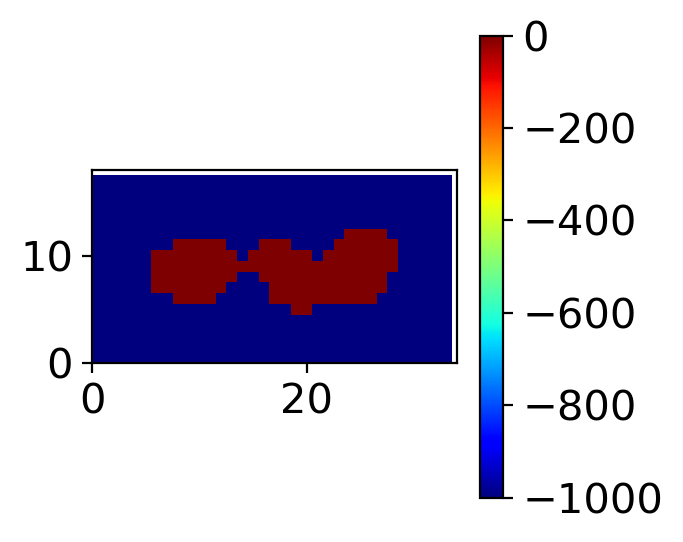

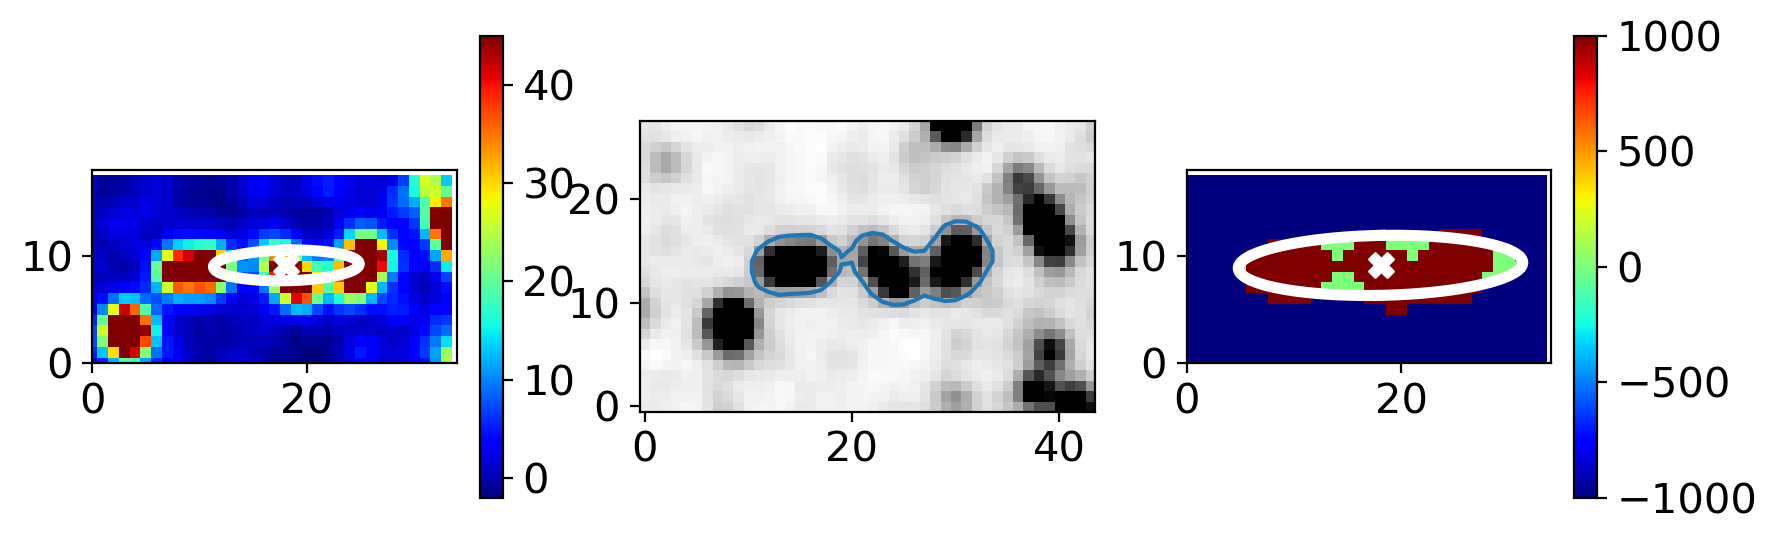

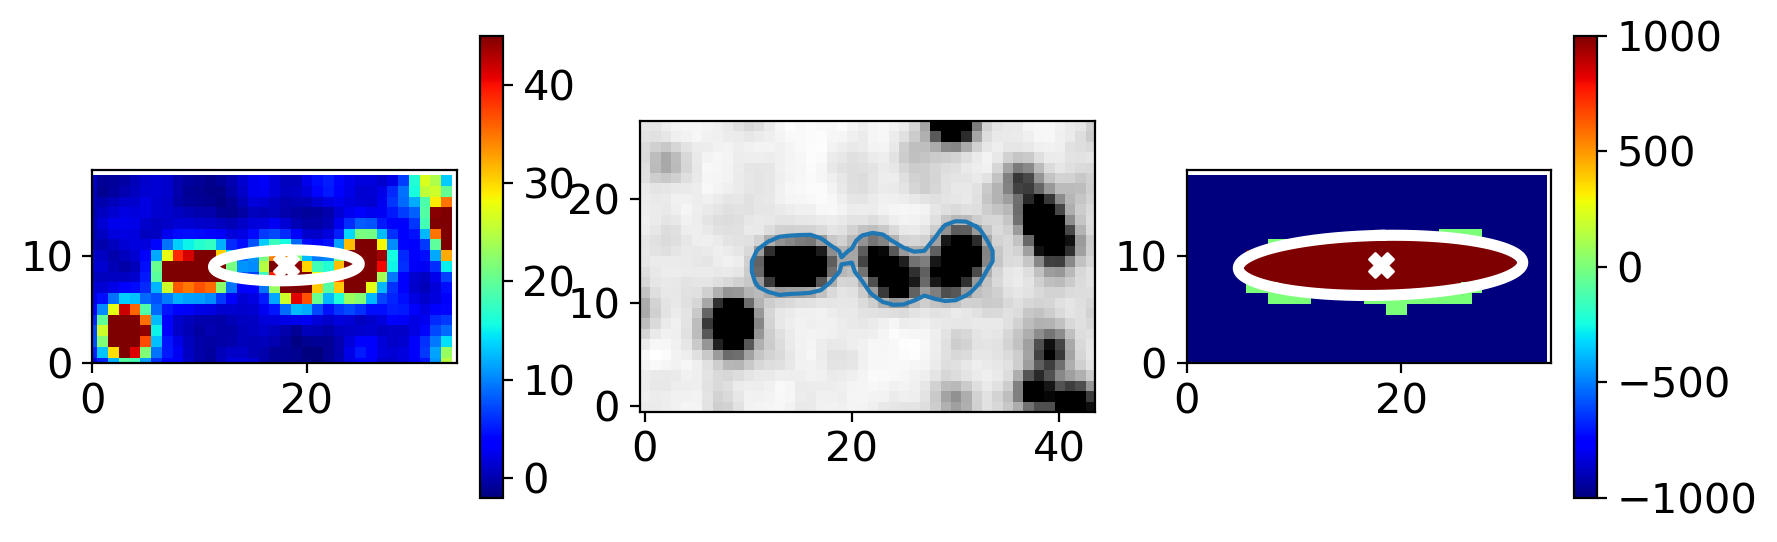

In [8]:
key = '1110199_10_1'

vertices = conservativeHigherVertices.get(key)
print('The contour key is ' + str(key))

contourGrid(vertices, usefulImagePrime, 5)

function1 = Area1Calculate(vertices, usefulImagePrime, 5, 0)
function2 = Area2Calculate(vertices, usefulImagePrime, 5, 0)

#Save properties to values 
contourArea = function1[0]
area1 = function1[1]
area2 = function2

print('The isophote''s area is: ' + str(contourArea))
print('The area outside isophote but inside the ellipse is: ' + str(area1))
print('The area inside isophote but outside the ellipse is: ' + str(area2))

ellipseness = 1 - ((area2 + area1)/(2*contourArea))

print('The ellipseness of the isophote is: ' + str(ellipseness))

The contour key is 547284_1000_0
The isophotes area is: 166.14153052692632
The area outside isophote but inside the ellipse is: 19
The area inside isophote but outside the ellipse is: 17
The ellipseness of the isophote is: 0.8916586362066602


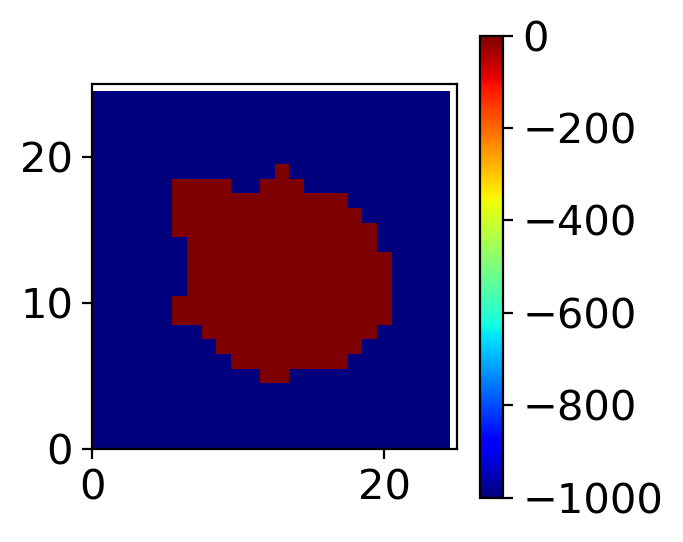

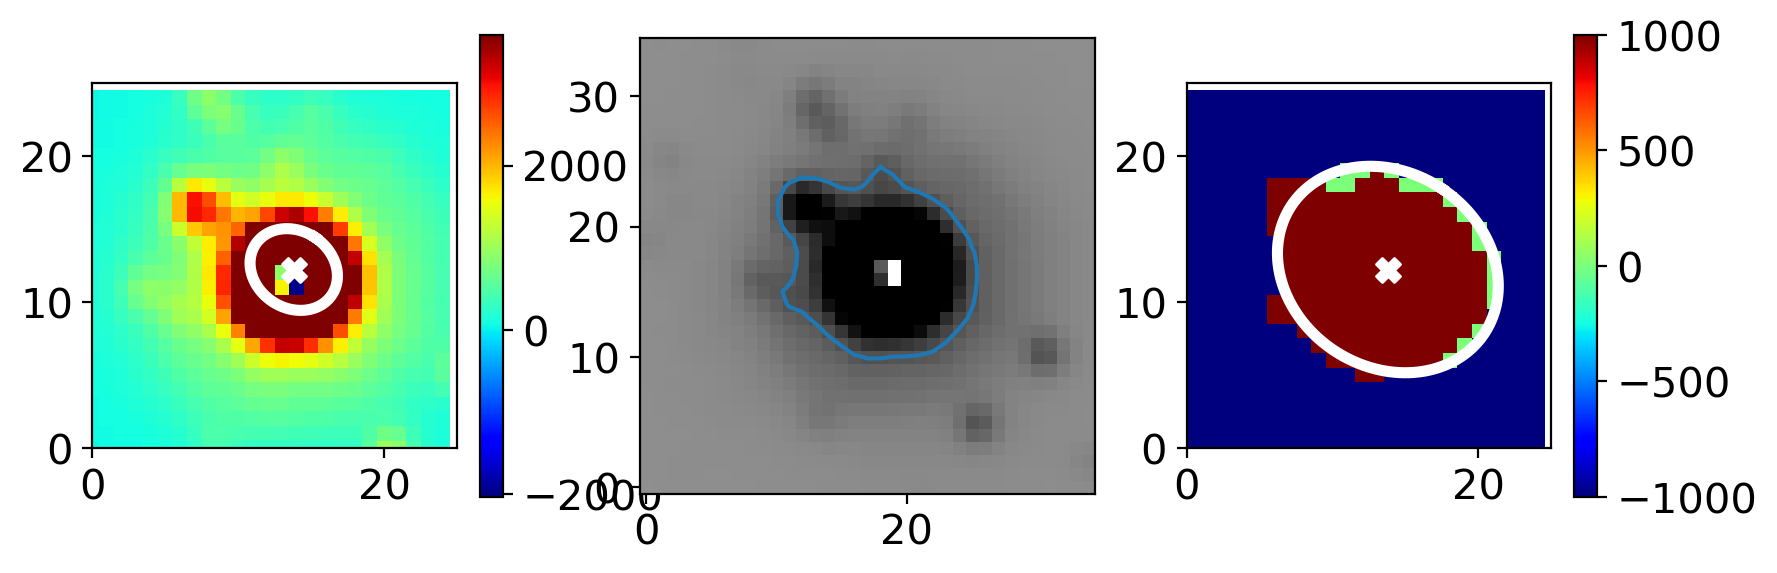

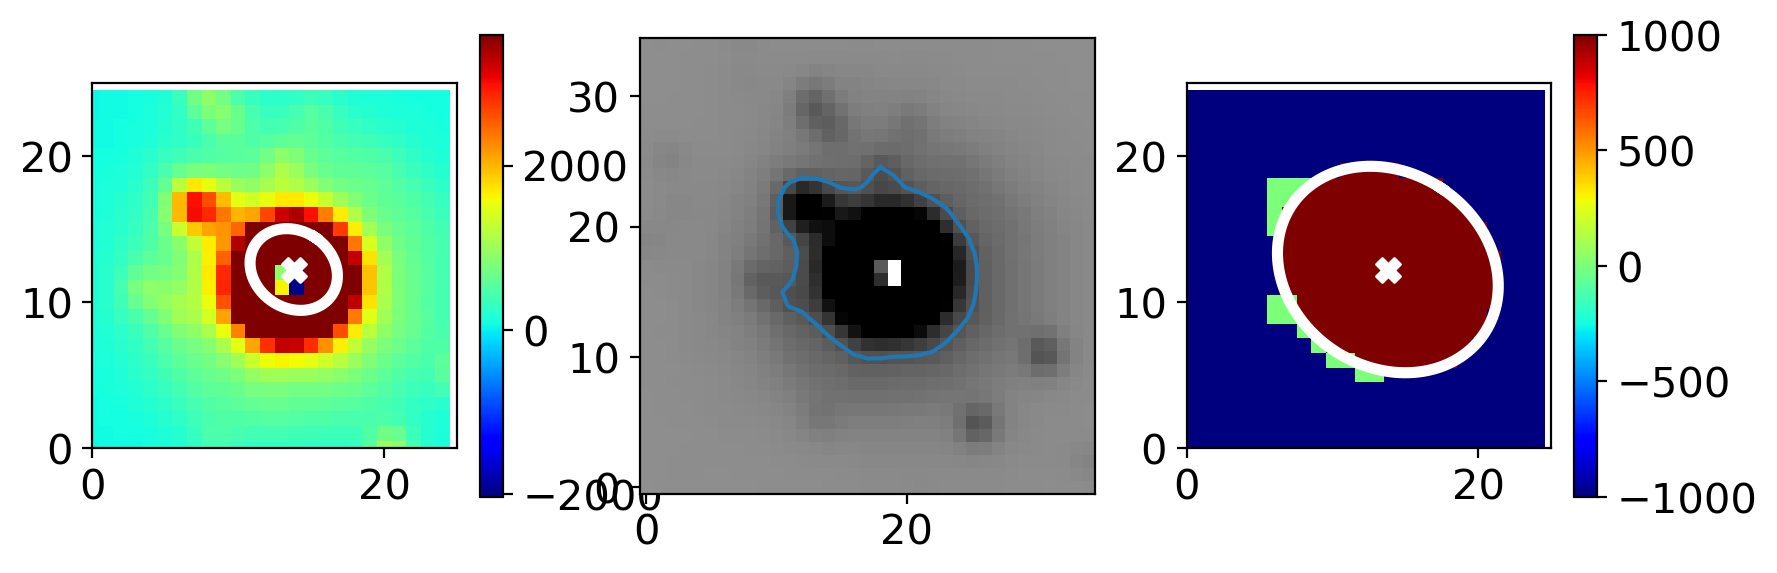

In [9]:
key = '547284_1000_0'

vertices = conservativeHigherVertices.get(key)
print('The contour key is ' + str(key))

contourGrid(vertices, usefulImagePrime, 5)

function1 = Area1Calculate(vertices, usefulImagePrime, 5, 0)
function2 = Area2Calculate(vertices, usefulImagePrime, 5, 0)

#Save properties to values 
contourArea = function1[0]
area1 = function1[1]
area2 = function2

print('The isophote''s area is: ' + str(contourArea))
print('The area outside isophote but inside the ellipse is: ' + str(area1))
print('The area inside isophote but outside the ellipse is: ' + str(area2))

ellipseness = 1 - ((area2 + area1)/(2*contourArea))

print('The ellipseness of the isophote is: ' + str(ellipseness))

The contour key is 713644_25_0
The isophotes area is: 241.6995785799621
The area outside isophote but inside the ellipse is: 28
The area inside isophote but outside the ellipse is: 27
The ellipseness of the isophote is: 0.8862223916087545


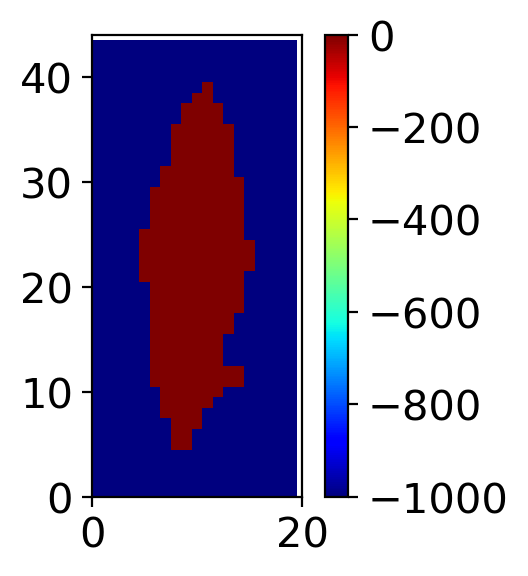

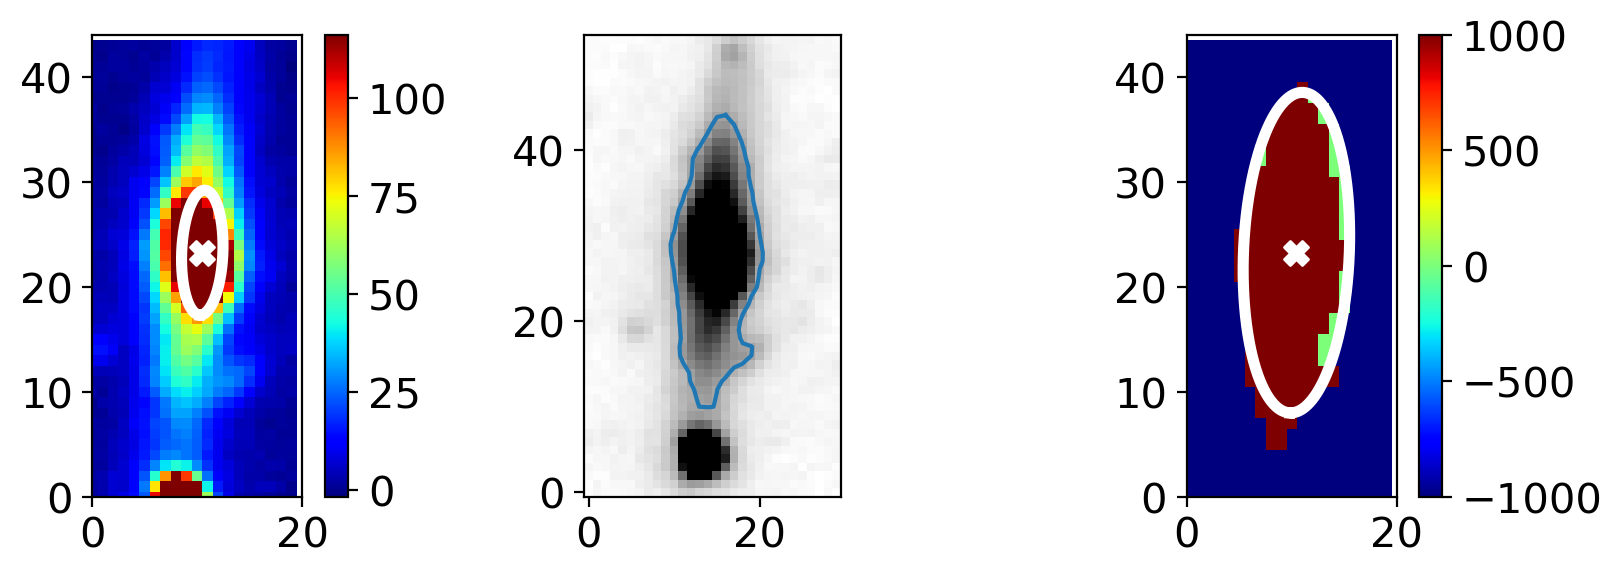

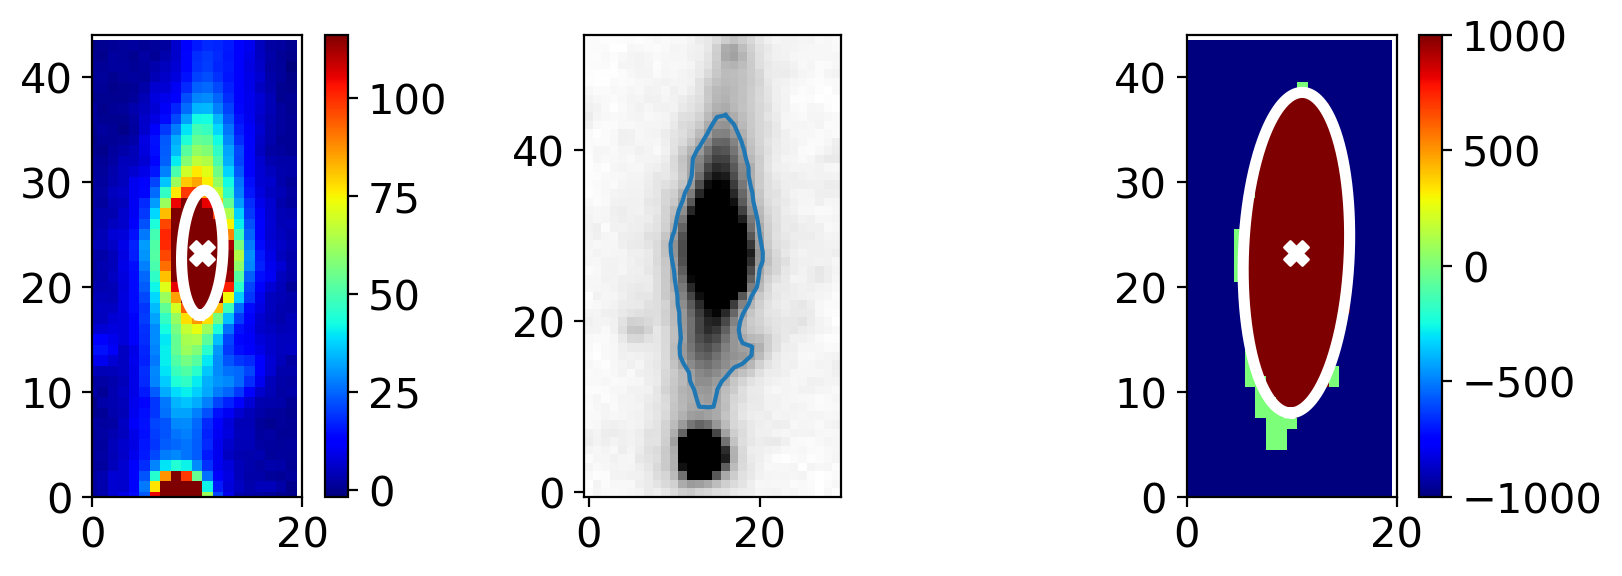

In [10]:
key = '713644_25_0'

vertices = conservativeHigherVertices.get(key)
print('The contour key is ' + str(key))

contourGrid(vertices, usefulImagePrime, 5)

function1 = Area1Calculate(vertices, usefulImagePrime, 5, 0)
function2 = Area2Calculate(vertices, usefulImagePrime, 5, 0)

#Save properties to values 
contourArea = function1[0]
area1 = function1[1]
area2 = function2

print('The isophote''s area is: ' + str(contourArea))
print('The area outside isophote but inside the ellipse is: ' + str(area1))
print('The area inside isophote but outside the ellipse is: ' + str(area2))

ellipseness = 1 - ((area2 + area1)/(2*contourArea))

print('The ellipseness of the isophote is: ' + str(ellipseness))

In [ ]:
#Create a dictionary to store the ratio values
conservativeHigherAreas = {}
conservativeHigherAreas['key'] = []
conservativeHigherAreas['Isophote Area'] = []
conservativeHigherAreas['EllipseOutsideIsophote'] = []
conservativeHigherAreas['IsophoteOutsideEllipse'] = []
conservativeHigherAreas['Ellipseness'] = []

#faultyContours = np.load(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\scaledFaultyContoursV2(1-19-25).npy")
faultyContours = np.load(r"C:\Users\jacob\OneDrive\Desktop\Cluster_Project\sf1.npy")
#Find the areas and save them
for key in conservativeHigherVertices:
    
    #if key == '310567_10_27':
        #continue
    #if key == '310567_25_26':
        #continue
    
   
    vertices = conservativeHigherVertices.get(key)
    print('The contour key is ' + str(key))
    
    if key in faultyContours:
        continue
    
    function1 = Area1Calculate(vertices, usefulImagePrime, 5, 1)
    function2 = Area2Calculate(vertices, usefulImagePrime, 5, 1)
    
    #Save properties to values 
    contourArea = function1[0]
    area1 = function1[1]
    area2 = function2
    
    print('The isophote''s area is: ' + str(contourArea))
    print('The area outside isophote but inside the ellipse is: ' + str(area1))
    print('The area inside isophote but outside the ellipse is: ' + str(area2))
    
    #Calculate the parameter of interest
    ellipseness = 1 - ((area2 + area1)/(2*contourArea))
    
    print('The ellipseness of the isophote is: ' + str(ellipseness))
    
    
    print()
    
    conservativeHigherAreas['key'].append(key)
    conservativeHigherAreas['Isophote Area'].append(contourArea)
    conservativeHigherAreas['EllipseOutsideIsophote'].append(area1)
    conservativeHigherAreas['IsophoteOutsideEllipse'].append(area2)
    conservativeHigherAreas['Ellipseness'].append(ellipseness)
    
    
#Save the parameters to a table and print said table    
conservativeHigherAreas_table = Table(conservativeHigherAreas)
print(conservativeHigherAreas_table)   
#conservativeHigherAreas_table.write('ConservativeHigherAreasandEllipseness(UPDATED_1-2).fits', overwrite = True)

    
    

In [ ]:
expansiveHigherVertices.keys()

Expansive Higher Checks

The contour key is 499094_1425_1


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


The isophotes area is: 95.32811301584047
The area outside isophote but inside the ellipse is: 10
The area inside isophote but outside the ellipse is: 11
The ellipseness of the isophote is: 0.8898541084280642


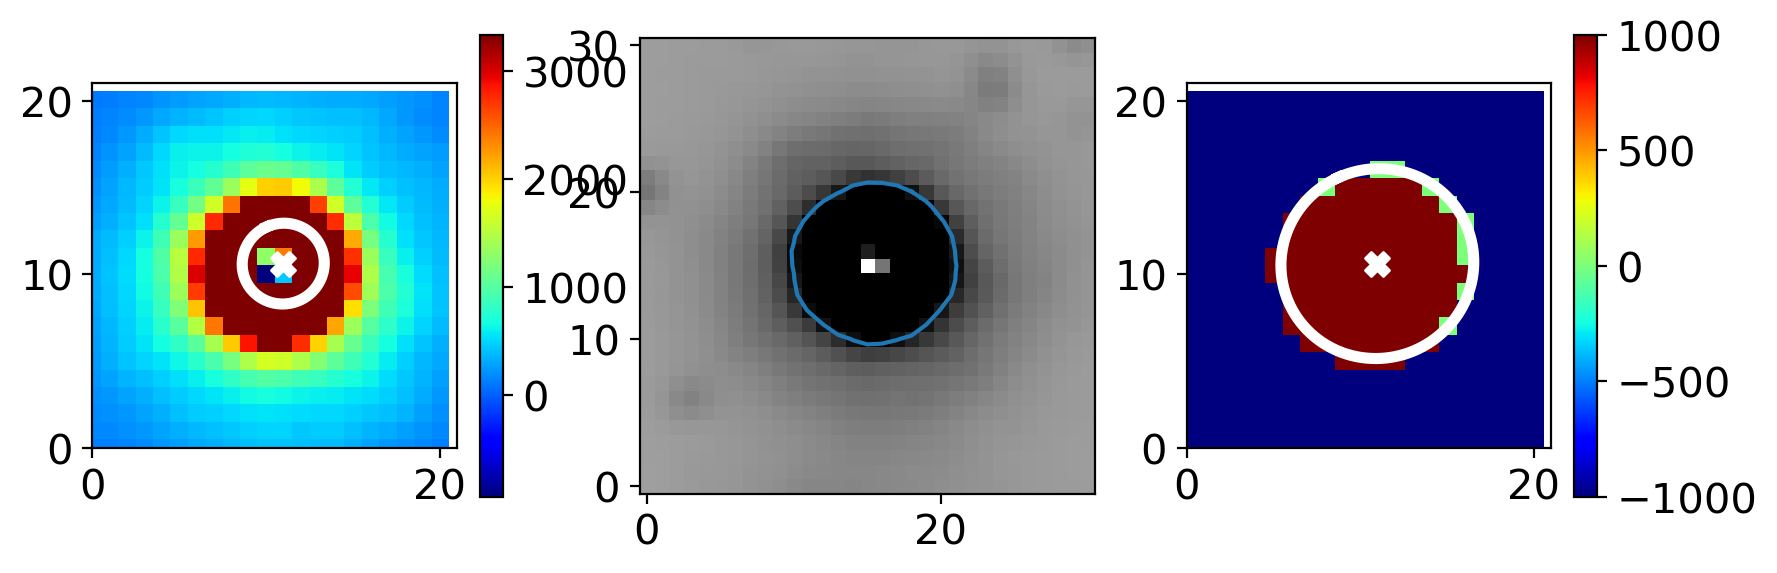

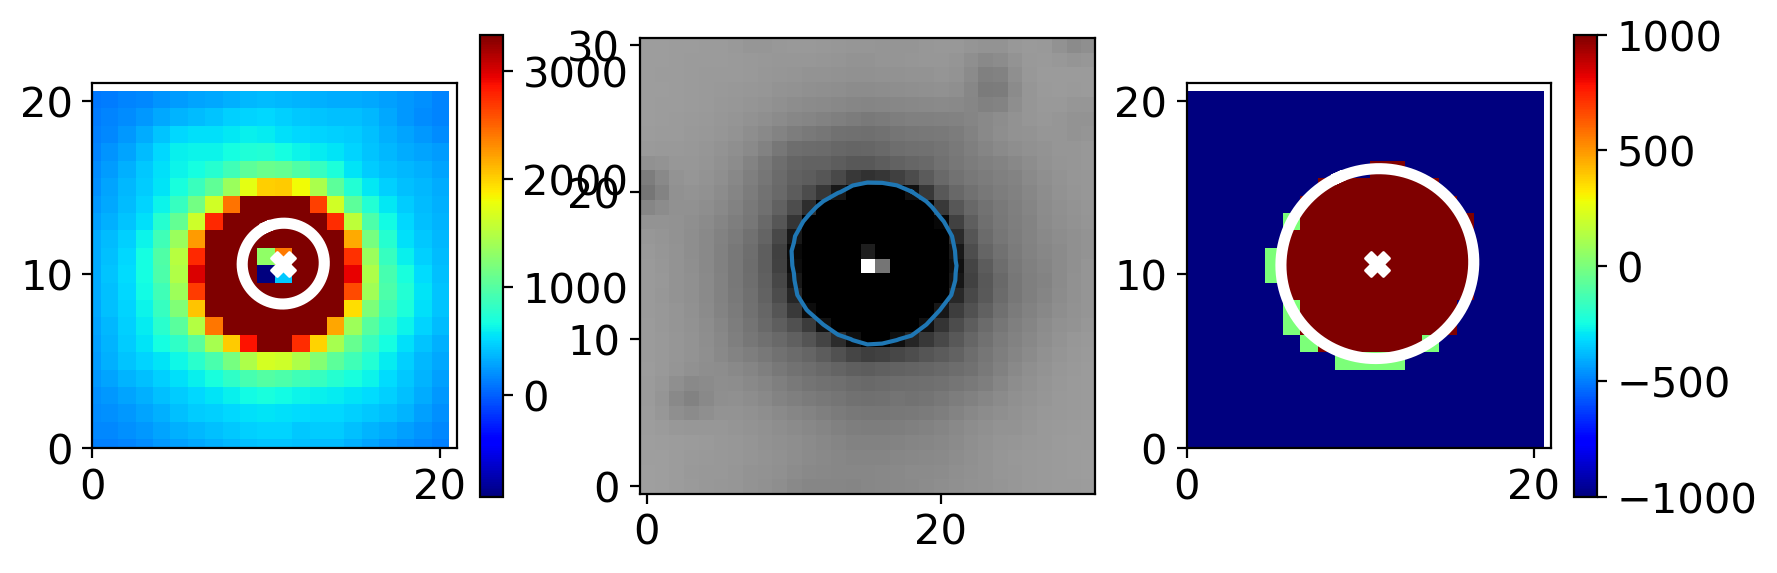

In [23]:
key = '499094_1425_1'

vertices = expansiveHigherVertices.get(key)
print('The contour key is ' + str(key))

function1 = Area1Calculate(vertices, usefulImage, 5, 0)
function2 = Area2Calculate(vertices, usefulImage, 5, 0)

#Save properties to values 
contourArea = function1[0]
area1 = function1[1]
area2 = function2

print('The isophote''s area is: ' + str(contourArea))
print('The area outside isophote but inside the ellipse is: ' + str(area1))
print('The area inside isophote but outside the ellipse is: ' + str(area2))

ellipseness = 1 - ((area2 + area1)/(2*contourArea))

print('The ellipseness of the isophote is: ' + str(ellipseness))

The contour key is 1377277_15_10
The isophotes area is: 88.74473768952976
The area outside isophote but inside the ellipse is: 24
The area inside isophote but outside the ellipse is: 23
The ellipseness of the isophote is: 0.7351955663871148


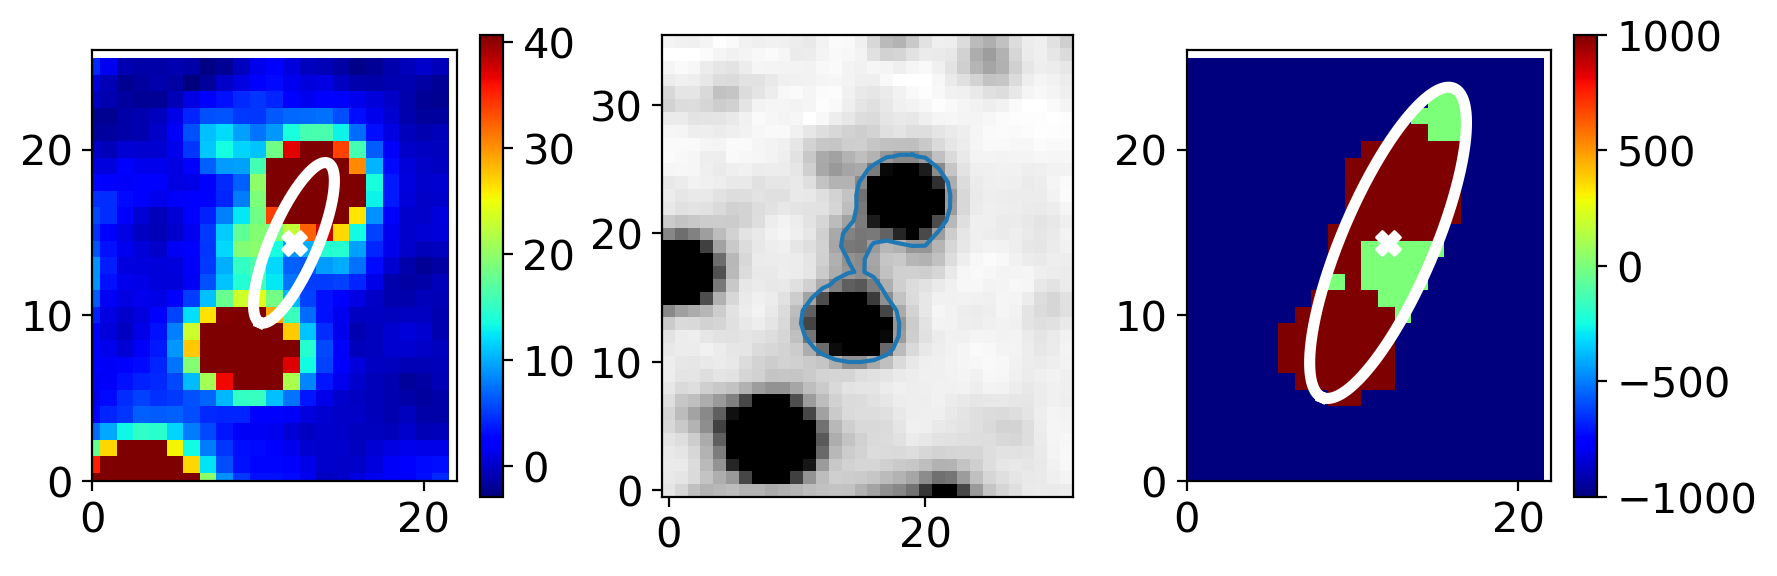

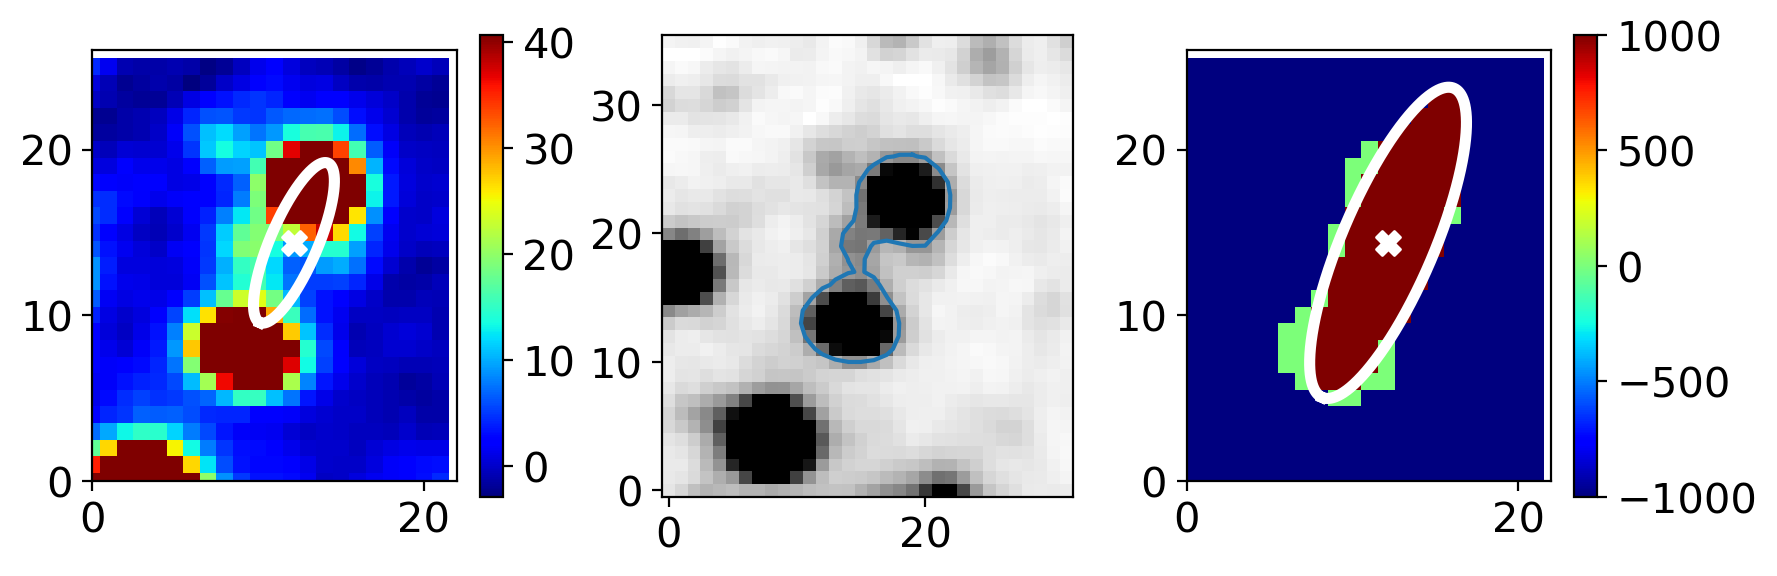

In [24]:
key = '1377277_15_10'

vertices = expansiveHigherVertices.get(key)
print('The contour key is ' + str(key))

function1 = Area1Calculate(vertices, usefulImage, 5, 0)
function2 = Area2Calculate(vertices, usefulImage, 5, 0)

#Save properties to values 
contourArea = function1[0]
area1 = function1[1]
area2 = function2

print('The isophote''s area is: ' + str(contourArea))
print('The area outside isophote but inside the ellipse is: ' + str(area1))
print('The area inside isophote but outside the ellipse is: ' + str(area2))

ellipseness = 1 - ((area2 + area1)/(2*contourArea))

print('The ellipseness of the isophote is: ' + str(ellipseness))

The contour key is 585704_830_2
The isophotes area is: 165.60054488815416
The area outside isophote but inside the ellipse is: 10
The area inside isophote but outside the ellipse is: 11
The ellipseness of the isophote is: 0.9365944115275004


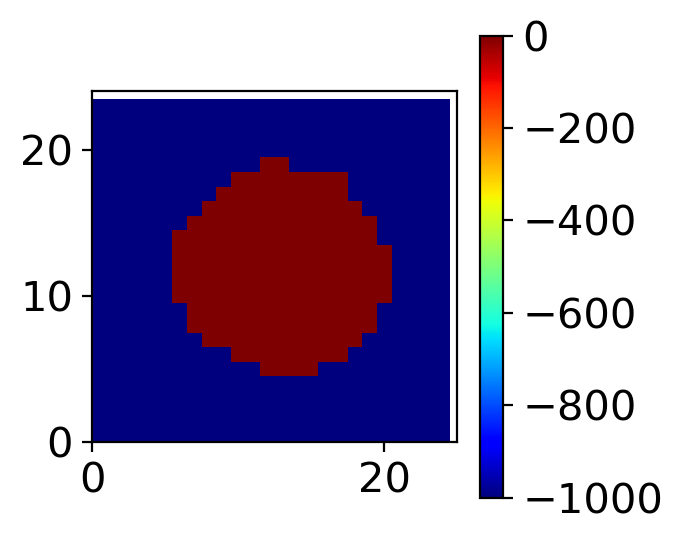

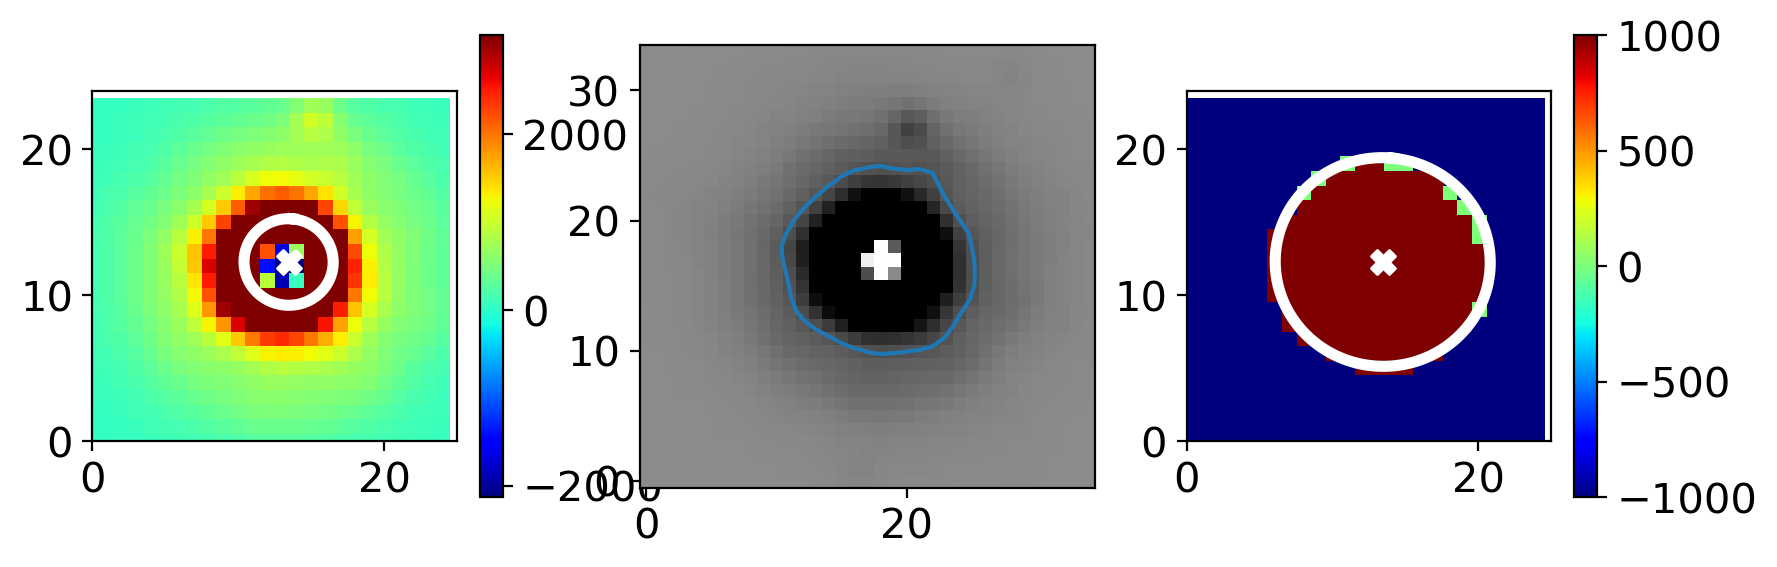

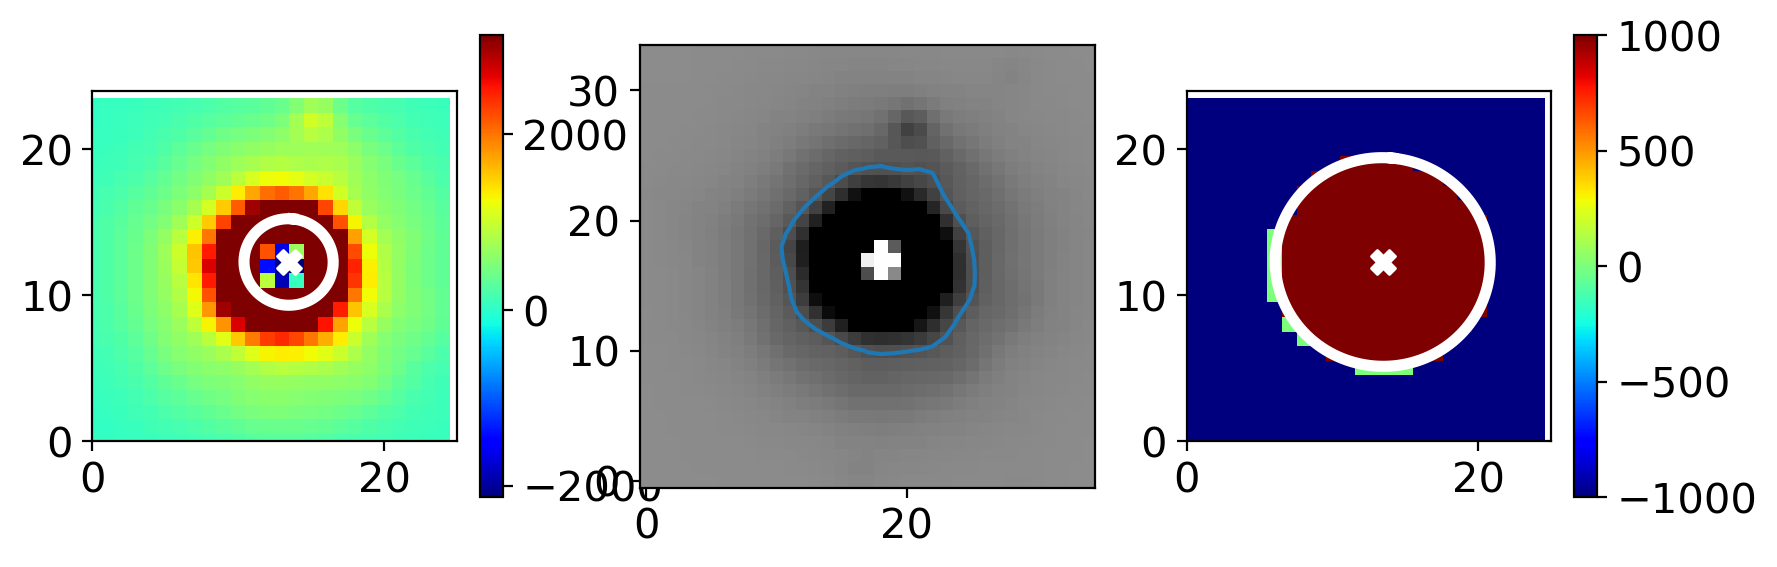

In [11]:
key = '585704_830_2'

vertices = expansiveHigherVertices.get(key)
print('The contour key is ' + str(key))

contourGrid(vertices, usefulImage, 5)

function1 = Area1Calculate(vertices, usefulImage, 5, 0)
function2 = Area2Calculate(vertices, usefulImage, 5, 0)

#Save properties to values 
contourArea = function1[0]
area1 = function1[1]
area2 = function2

print('The isophote''s area is: ' + str(contourArea))
print('The area outside isophote but inside the ellipse is: ' + str(area1))
print('The area inside isophote but outside the ellipse is: ' + str(area2))

ellipseness = 1 - ((area2 + area1)/(2*contourArea))

print('The ellipseness of the isophote is: ' + str(ellipseness))

In [ ]:
#Create a dictionary to store the ratio values
expansiveHigherAreas = {}
expansiveHigherAreas['key'] = []
expansiveHigherAreas['Isophote Area'] = []
expansiveHigherAreas['EllipseOutsideIsophote'] = []
expansiveHigherAreas['IsophoteOutsideEllipse'] = []
expansiveHigherAreas['Ellipseness'] = []


#Find the areas and save them
for key in expansiveHigherVertices:
    vertices = expansiveHigherVertices.get(key)
    print('The contour key is ' + str(key))
    
    if key == '375545_10_209':
        continue
    if key == '375545_25_179':
        continue
    
    
    function1 = Area1Calculate(vertices, usefulImage, 5, 1)
    function2 = Area2Calculate(vertices, usefulImage, 5, 1)
    
    #Save properties to values 
    contourArea = function1[0]
    area1 = function1[1]
    area2 = function2
    
    print('The isophote''s area is: ' + str(contourArea))
    print('The area outside isophote but inside the ellipse is: ' + str(area1))
    print('The area inside isophote but outside the ellipse is: ' + str(area2))
    
    #Calculate the parameter of interest
    ellipseness = 1 - ((area2 + area1)/(2*contourArea))
    
    print('The ellipseness of the isophote is: ' + str(ellipseness))
    
    
    print()
    
    expansiveHigherAreas['key'].append(key)
    expansiveHigherAreas['Isophote Area'].append(contourArea)
    expansiveHigherAreas['EllipseOutsideIsophote'].append(area1)
    expansiveHigherAreas['IsophoteOutsideEllipse'].append(area2)
    expansiveHigherAreas['Ellipseness'].append(ellipseness)
    
    
#Save the parameters to a table and print said table    
expansiveHigherAreas_table = Table(expansiveHigherAreas)
print(expansiveHigherAreas_table)   
expansiveHigherAreas_table.write('ExpansiveHigherAreasandEllipseness(UPDATED_1-2).fits', overwrite = True)

    
    